1. Setup

In [1]:
# =========================================================
# Librerías base
# =========================================================
import os
import sys
import importlib
import joblib

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# Detecta la raíz del proyecto
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz al path para importar configuración
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa configuración
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)

FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full


2. Cargar resultados de multiclase y binario

In [2]:
# ---------------------------------------------------------
# Carga resultados del benchmark multiclase full
# ---------------------------------------------------------
multiclass_results = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "multiclass_model_results_full.csv")
)

# ---------------------------------------------------------
# Carga resultados del benchmark binario full
# ---------------------------------------------------------
binary_results = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "binary_model_results_full.csv")
)

print("Resultados multiclase:")
display(multiclass_results)

print("Resultados binarios:")
display(binary_results)

Resultados multiclase:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Random Forest Full,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290
1,LightGBM Full,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743


Resultados binarios:


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest Binary Full,0.980129,0.999739,0.979650,0.989592,0.998654
1,LightGBM Binary Full,0.978305,0.999759,0.977739,0.988626,0.998965
2,XGBoost Binary Full,0.977875,0.999725,0.977326,0.988399,0.998773


3. Ordenar resultados

In [3]:
# ---------------------------------------------------------
# Ordenar resultados multiclase por F1 weighted
# ---------------------------------------------------------
multiclass_results = multiclass_results.sort_values(
    by="f1_weighted", ascending=False
).reset_index(drop=True)

# ---------------------------------------------------------
# Ordenar resultados binarios por F1
# ---------------------------------------------------------
binary_results = binary_results.sort_values(
    by="f1", ascending=False
).reset_index(drop=True)

print("Multiclase ordenado:")
display(multiclass_results)

print("Binario ordenado:")
display(binary_results)

Multiclase ordenado:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Random Forest Full,0.947053,0.973984,0.947053,0.956986,0.807870,0.916930,0.824290
1,LightGBM Full,0.942246,0.973408,0.942246,0.953412,0.754607,0.951583,0.778039
2,XGBoost Full Balanced,0.938730,0.972070,0.938730,0.950576,0.746761,0.952800,0.767743


Binario ordenado:


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest Binary Full,0.980129,0.999739,0.979650,0.989592,0.998654
1,LightGBM Binary Full,0.978305,0.999759,0.977739,0.988626,0.998965
2,XGBoost Binary Full,0.977875,0.999725,0.977326,0.988399,0.998773


4. Gráfico comparativo multiclase

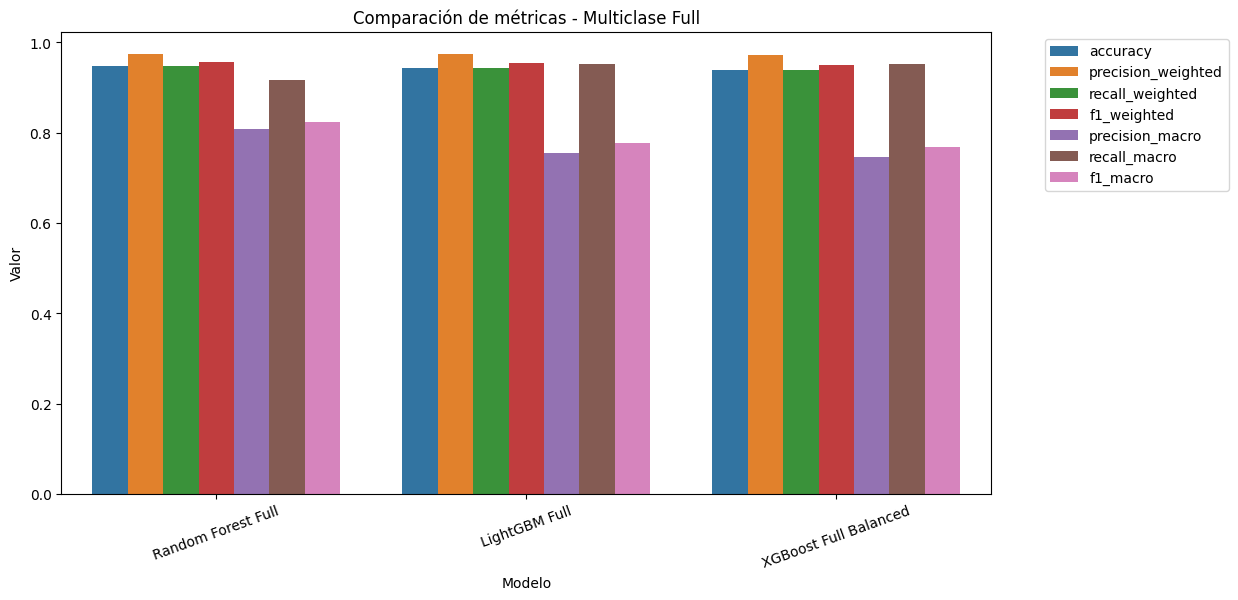

In [4]:
# ---------------------------------------------------------
# Convierte los resultados multiclase a formato largo
# para graficar varias métricas por modelo
# ---------------------------------------------------------
multiclass_metrics = multiclass_results.melt(
    id_vars="model",
    value_vars=[
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=multiclass_metrics, x="model", y="value", hue="metric")
plt.title("Comparación de métricas - Multiclase Full")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

5. Gráfico comparativo binario

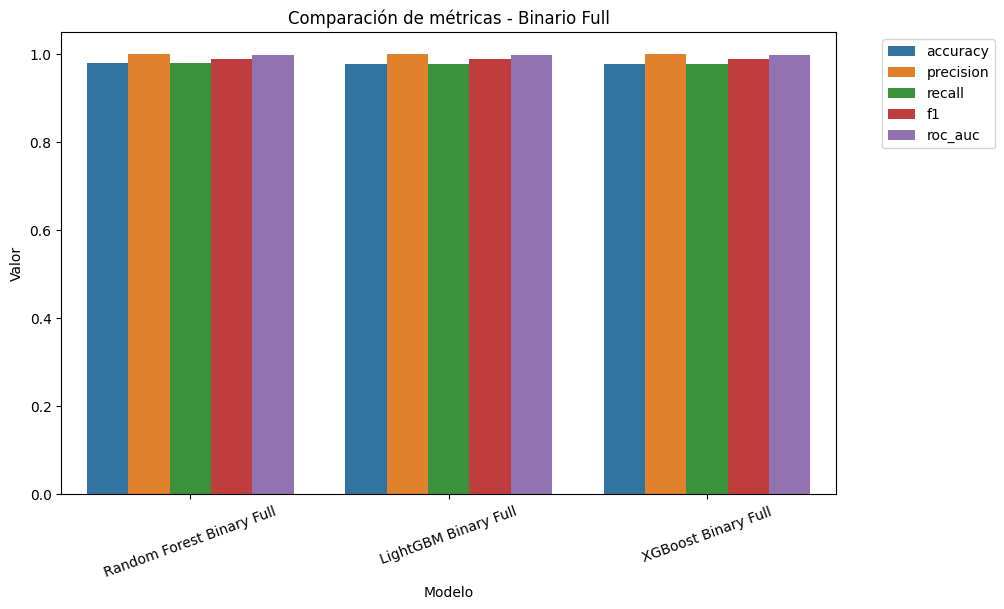

In [5]:
# ---------------------------------------------------------
# Convierte resultados binarios a formato largo
# ---------------------------------------------------------
binary_metrics = binary_results.melt(
    id_vars="model",
    value_vars=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=binary_metrics, x="model", y="value", hue="metric")
plt.title("Comparación de métricas - Binario Full")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

6. Identificar mejor modelo de cada enfoque

In [6]:
# ---------------------------------------------------------
# Mejor modelo multiclase según F1 weighted
# ---------------------------------------------------------
best_multiclass = multiclass_results.iloc[0]

# ---------------------------------------------------------
# Mejor modelo binario según F1
# ---------------------------------------------------------
best_binary = binary_results.iloc[0]

print("Mejor modelo multiclase:")
print(best_multiclass)

print("\nMejor modelo binario:")
print(best_binary)

Mejor modelo multiclase:
model                 Random Forest Full
accuracy                        0.947053
precision_weighted              0.973984
recall_weighted                 0.947053
f1_weighted                     0.956986
precision_macro                  0.80787
recall_macro                     0.91693
f1_macro                         0.82429
Name: 0, dtype: object

Mejor modelo binario:
model        Random Forest Binary Full
accuracy                      0.980129
precision                     0.999739
recall                         0.97965
f1                            0.989592
roc_auc                       0.998654
Name: 0, dtype: object


7. Cargar predicciones guardadas

In [7]:
# ---------------------------------------------------------
# Carga predicciones multiclase
# ---------------------------------------------------------
rf_multi_pred = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "rf_predictions_full.csv")
)

xgb_multi_pred = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_predictions_full.csv")
)

lgb_multi_pred = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_predictions_full.csv")
)

In [8]:
# ---------------------------------------------------------
# Carga predicciones binarias
# ---------------------------------------------------------
rf_bin_pred = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "rf_binary_predictions_full.csv")
)

xgb_bin_pred = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_binary_predictions_full.csv")
)

lgb_bin_pred = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "lgb_binary_predictions_full.csv")
)

8. Reconstruir nombres de clases multiclase

In [9]:
# ---------------------------------------------------------
# Reconstruye los nombres de clase multiclase
# desde el dataset consolidado full
# ---------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

df_full = pd.read_parquet(config.FULL_CONSOLIDATED_PATH)

target_encoder = LabelEncoder()
target_encoder.fit(df_full[config.MULTICLASS_TARGET].astype(str))

multiclass_class_names = list(target_encoder.classes_)
print("Clases multiclase:", multiclass_class_names)

Clases multiclase: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


9. Función para graficar matrices de confusión

In [10]:
# ---------------------------------------------------------
# Función genérica para graficar matrices de confusión
# ---------------------------------------------------------
def plot_confusion(y_true, y_pred, title, class_names, figsize=(12, 9), annot=False):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=annot,
        fmt="d" if annot else "",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

10. Matrices de confusión multiclase

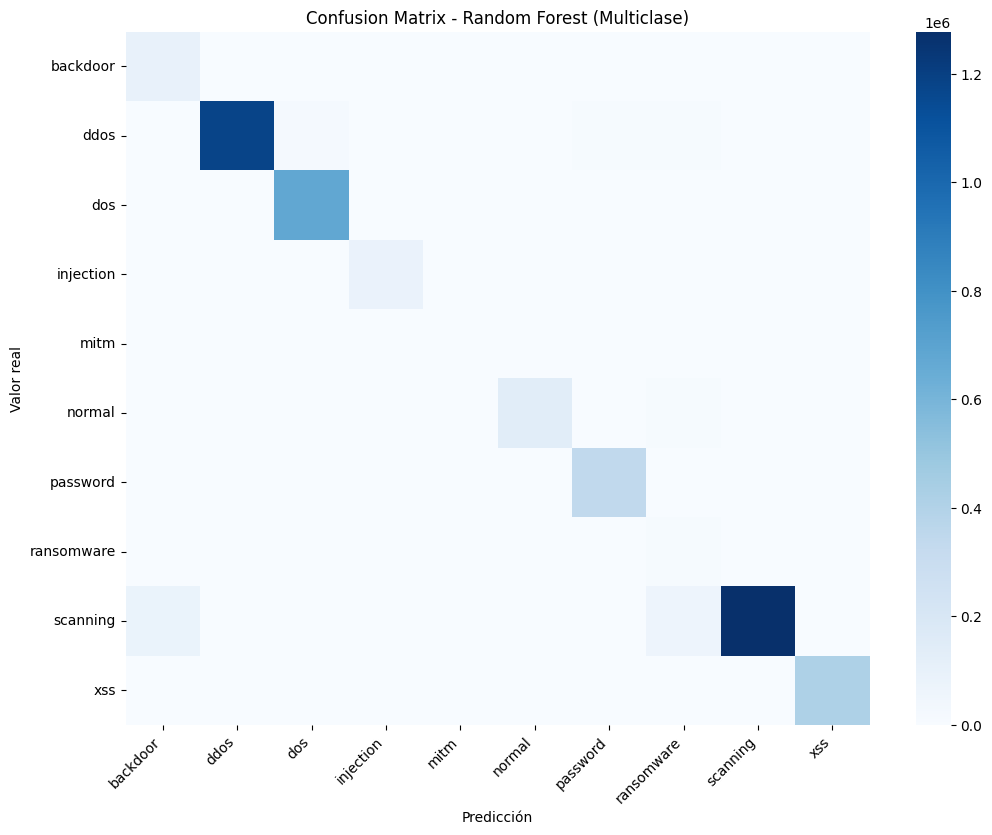

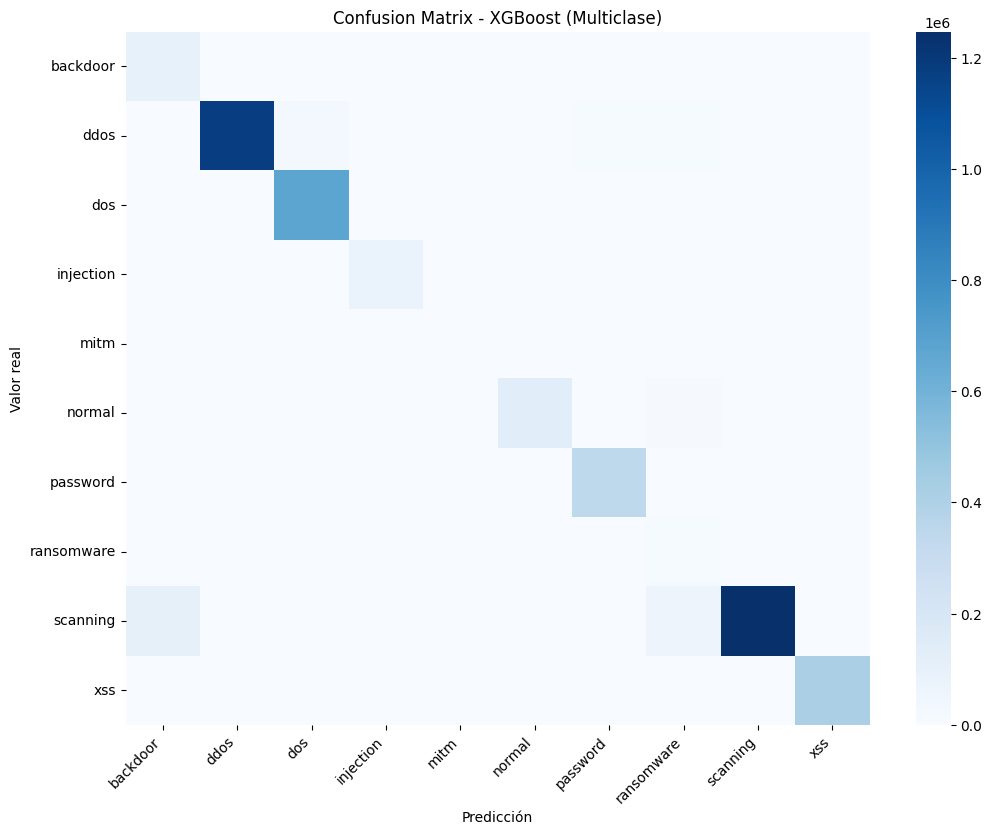

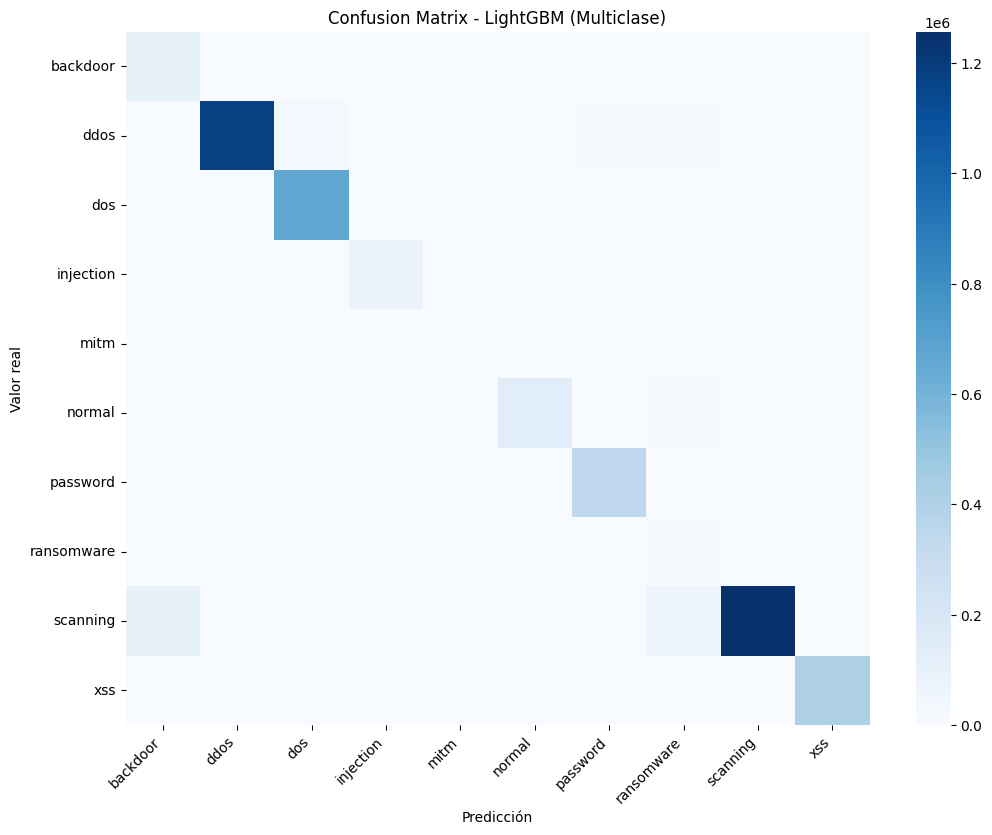

In [12]:
plot_confusion(
    rf_multi_pred["y_true"],
    rf_multi_pred["y_pred"],
    "Confusion Matrix - Random Forest (Multiclase)",
    multiclass_class_names,
    figsize=(12, 9),
    annot=False
)

plot_confusion(
    xgb_multi_pred["y_true"],
    xgb_multi_pred["y_pred"],
    "Confusion Matrix - XGBoost (Multiclase)",
    multiclass_class_names,
    figsize=(12, 9),
    annot=False
)

plot_confusion(
    lgb_multi_pred["y_true"],
    lgb_multi_pred["y_pred"],
    "Confusion Matrix - LightGBM (Multiclase)",
    multiclass_class_names,
    figsize=(12, 9),
    annot=False
)

11. Matrices de confusión binarias

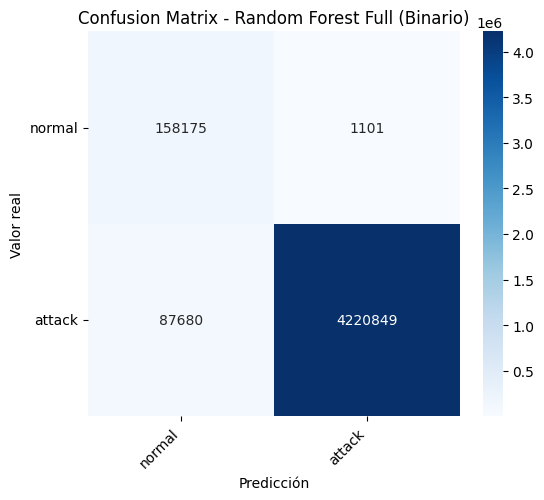

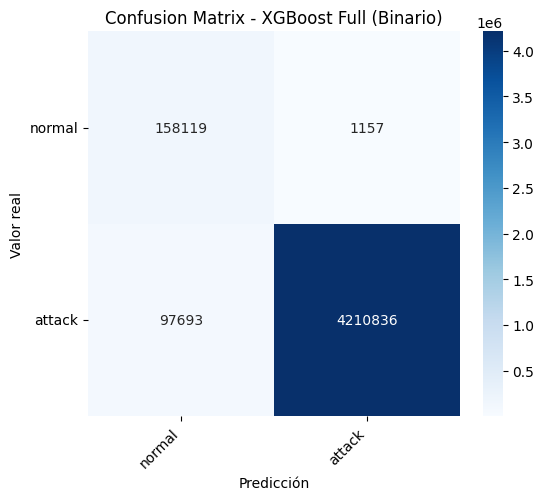

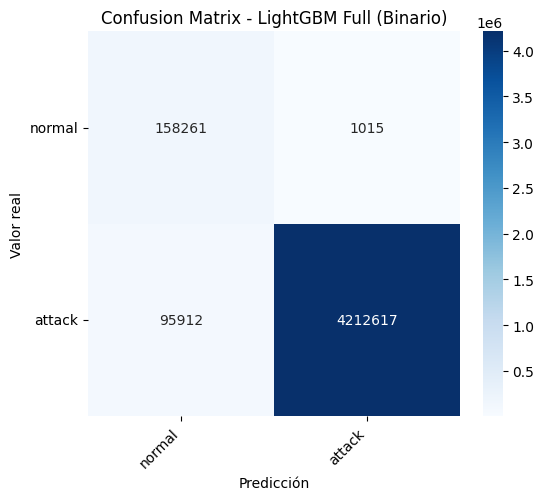

In [13]:
binary_class_names = ["normal", "attack"]

plot_confusion(
    rf_bin_pred["y_true"],
    rf_bin_pred["y_pred"],
    "Confusion Matrix - Random Forest Full (Binario)",
    binary_class_names,
    figsize=(6, 5),
    annot=True
)

plot_confusion(
    xgb_bin_pred["y_true"],
    xgb_bin_pred["y_pred"],
    "Confusion Matrix - XGBoost Full (Binario)",
    binary_class_names,
    figsize=(6, 5),
    annot=True
)

plot_confusion(
    lgb_bin_pred["y_true"],
    lgb_bin_pred["y_pred"],
    "Confusion Matrix - LightGBM Full (Binario)",
    binary_class_names,
    figsize=(6, 5),
    annot=True
)

12. Comparación rápida entre mejor multiclase y mejor binario

In [14]:
comparison_summary = pd.DataFrame([
    {
        "task": "multiclass_full",
        "best_model": best_multiclass["model"],
        "main_metric": "f1_weighted",
        "score": best_multiclass["f1_weighted"]
    },
    {
        "task": "binary_full",
        "best_model": best_binary["model"],
        "main_metric": "f1",
        "score": best_binary["f1"]
    }
])

comparison_summary

,task,best_model,main_metric,score
0,multiclass_full,Random Forest Full,f1_weighted,0.956986
1,binary_full,Random Forest Binary Full,f1,0.989592


13. Guardar resumen de evaluación

In [16]:
# ---------------------------------------------------------
# Guarda un resumen general de la evaluación full
# ---------------------------------------------------------
comparison_summary.to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "evaluation_summary_full.csv"),
    index=False
)

print("Resumen de evaluación guardado.")

Resumen de evaluación guardado.
